In [5]:
!pip install kagglehub

In [6]:
import kagglehub
import pandas as pd
import os

# Télécharger la dernière version du dataset officiel
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Trouver le fichier CSV dans le dossier téléchargé
csv_path = os.path.join(path, "creditcard.csv")

# Charger le DataFrame
df = pd.read_csv(csv_path)

# Vérifier
print("✅ Dataset chargé avec succès !")
print(f"Shape: {df.shape}")  # Doit afficher (284807, 31)
print("\nPremières lignes :")
print(df.head())
print("\nColonnes :")
print(df.columns.tolist())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
✅ Dataset chargé avec succès !
Shape: (284807, 31)

Premières lignes :
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.19

In [7]:
print("Proportion de fraudes :")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Proportion de fraudes :
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Using Colab cache for faster access to the 'creditcardfraud' dataset.
✅ Dataset chargé avec succès !
Shape: (284807, 31)

PROBLÉMATIQUE

Comment détecter des fraudes rares dans un grand volume de transactions
bancaires à partir de variables anonymisées (V1 à V28), du montant (Amount)
et du temps (Time) ?

Objectif : Construire un modèle capable de classer une transaction comme
frauduleuse (1) ou normale (0) avec un maximum de rappel (recall) pour
ne pas manquer de fraudes, tout en minimisant les faux positifs.


DESCRIPTION DU DATASET
- Nombre d'observations : 284807
- Nombre de variables : 31
- Variables : Time, V1 à V28 (anonymisées par PCA), Amount, Class
- Cible : Class (0 = normale, 1 = fraude)

Types de données :
float64    30
int64       1
Name: count, dtype: int64

Statistiques descriptives :
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.1683

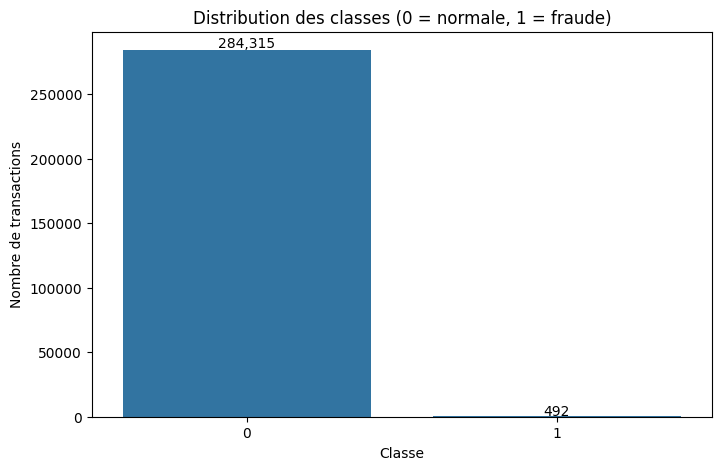

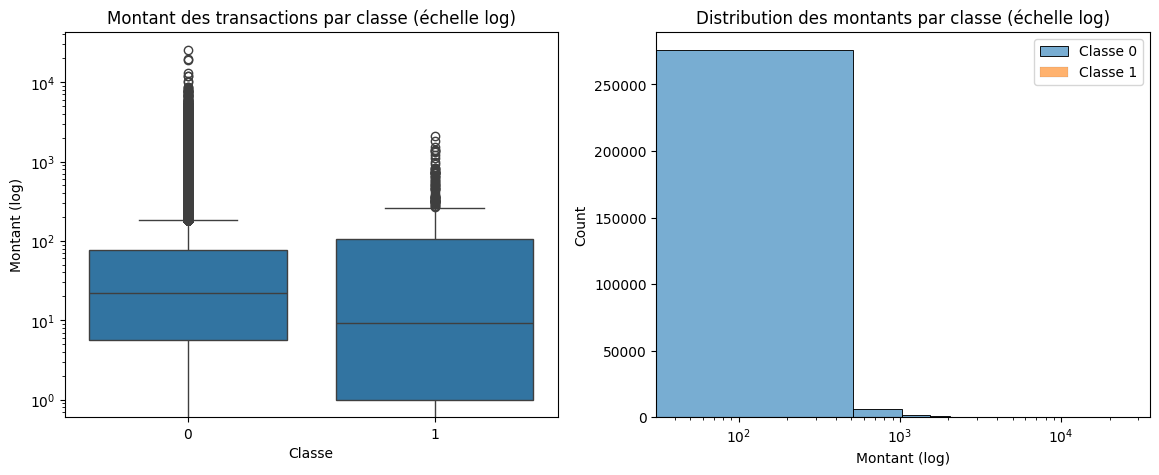


Visualisation de la matrice de corrélation (sur 1000 échantillons)...


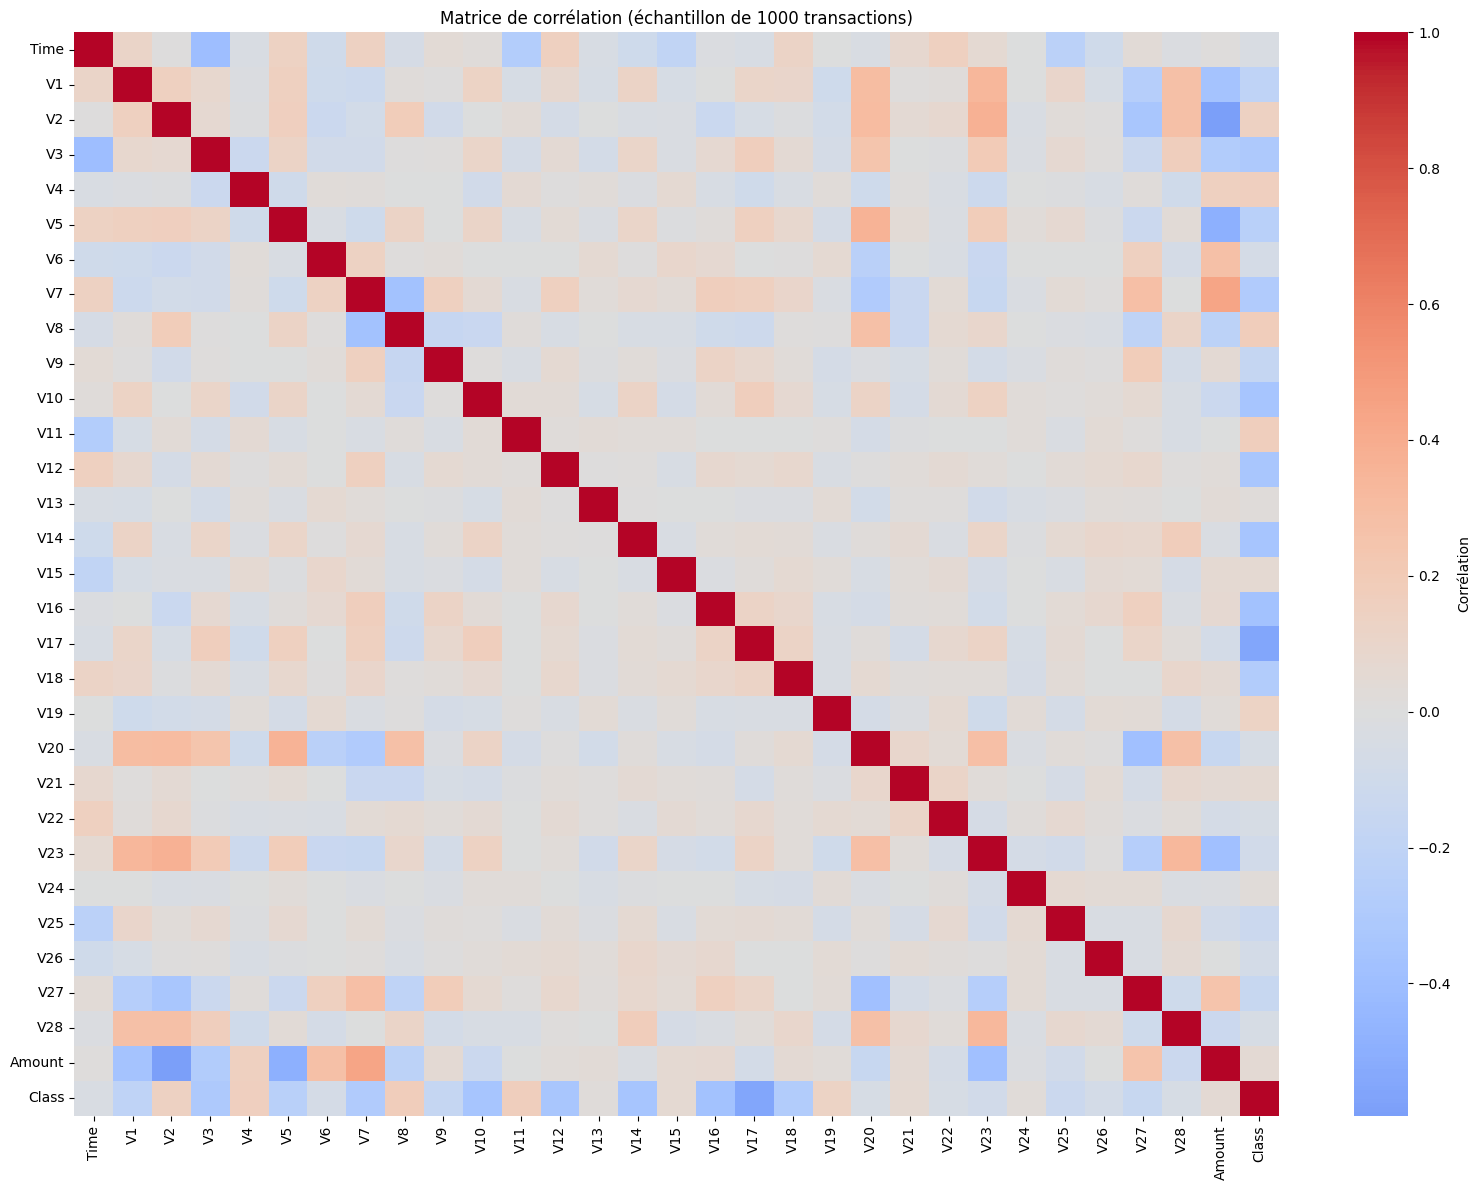

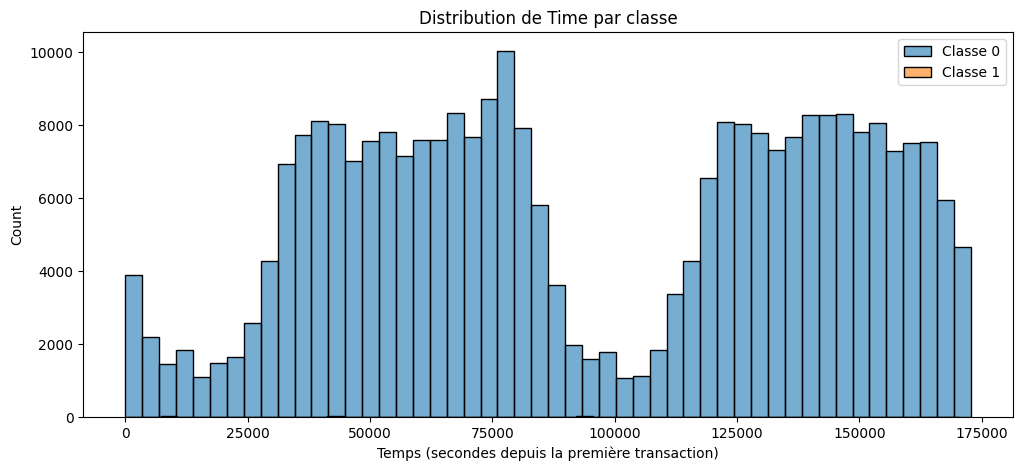


QUALITÉ DES DONNÉES ET NETTOYAGE
Valeurs manquantes : 0 (aucune !)
Doublons : 1081
Nombre de lignes uniques : 7875925
Outliers sur Amount (IQR) : 31904 transactions

✅ Aucun nettoyage nécessaire : pas de valeurs manquantes, pas de doublons.

FEATURE ENGINEERING
✅ Features 'TransactionHour' et 'TransactionDay' créées.

PRETRAITEMENT
✅ Amount, Time, TransactionHour et TransactionDay standardisés
Train : 227845 transactions
Test : 56962 transactions
Proportion de fraude dans train : 0.0017
Proportion de fraude dans test : 0.0017

MODELISATION
✅ Logistic Regression entraîné
✅ Random Forest entraîné
✅ Isolation Forest entraîné

EVALUATION

LOGISTIC REGRESSION (avec class_weight)
Accuracy  : 0.9732
Precision : 0.0555
Recall    : 0.9082
F1-Score  : 0.1046
ROC-AUC   : 0.9408
PR-AUC    : 0.0505

Matrice de confusion :
[[55349  1515]
 [    9    89]]

Rapport de classification :
              precision    recall  f1-score   support

     Normale       1.00      0.97      0.99     56864
      Fra

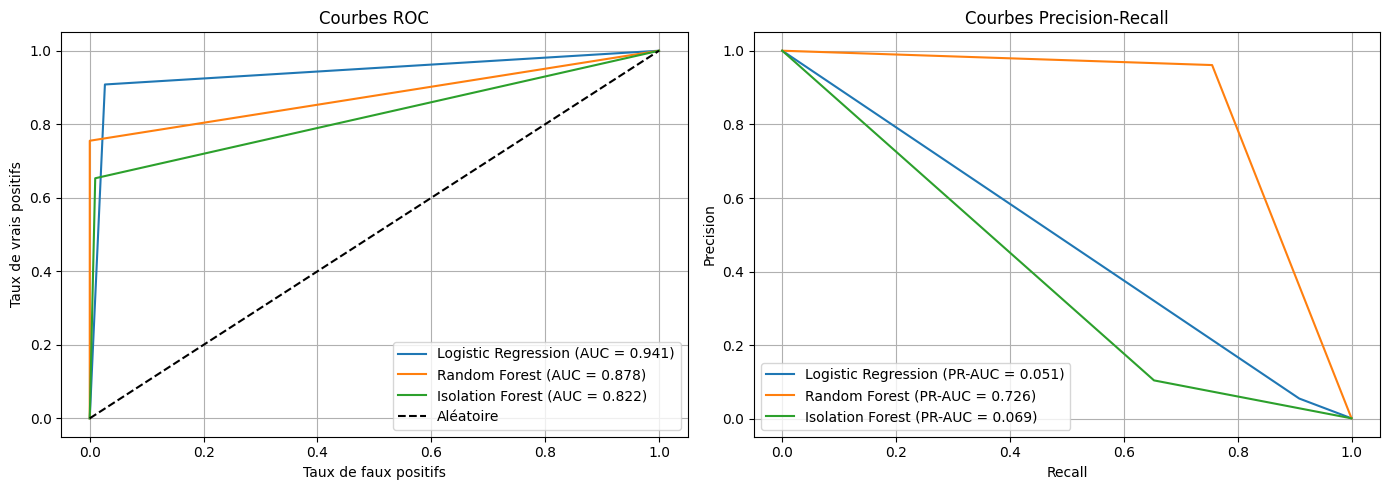


MATRICES DE CONFUSION - 2 SEUILS (Logistic Regression)


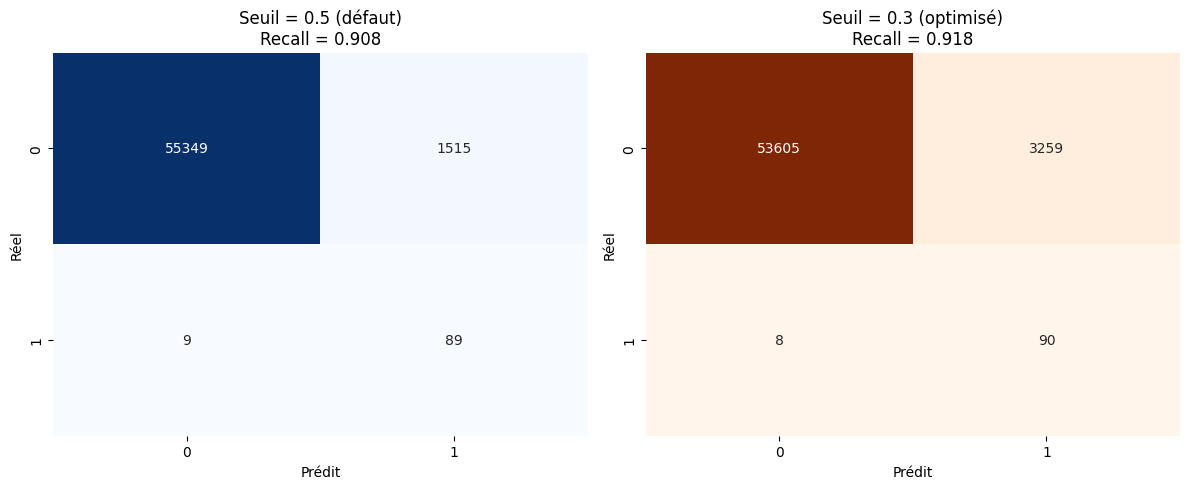


ANALYSE DES SEUILS :
- Seuil 0.5 (défaut) : favorise la précision, mais manque des fraudes.
- Seuil 0.3 (bas)    : favorise le rappel, détecte plus de fraudes,
                       mais augmente les faux positifs.
- Dans le contexte bancaire, il vaut mieux un seuil bas pour
  ne pas manquer de fraudes (coût des faux négatifs très élevé).


INTERPRETATION ET LIMITES

INTERPRÉTATION :
1. Le dataset est extrêmement déséquilibré (0.17% de fraudes).
2. Les variables V1 à V28 sont des composantes PCA anonymisées.
3. Random Forest donne le meilleur F1-score et PR-AUC.
4. Isolation Forest (non supervisé) est utile pour détecter les anomalies
   sans données labellisées, mais moins performant.

LIMITES :
1. Données anonymisées : impossible d'interpréter métier les variables V1-V28.
2. Données de 2013 : obsolètes pour une application réelle.
3. Pas de contexte temporel (Time est relatif, pas absolu).
4. Les modèles supervisés nécessitent des données labellisées (coût du labelling).

AMÉLIORAT

In [8]:
# ==========================================
# PROJET 18 - DÉTECTION DE FRAUDE BANCAIRE
# ==========================================

# 01_import_libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# 02_load_dataset
import kagglehub
import os

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

print("✅ Dataset chargé avec succès !")
print(f"Shape: {df.shape}")

# 03_problem_understanding
print("\n" + "="*50)
print("PROBLÉMATIQUE")
print("="*50)
print("""
Comment détecter des fraudes rares dans un grand volume de transactions
bancaires à partir de variables anonymisées (V1 à V28), du montant (Amount)
et du temps (Time) ?

Objectif : Construire un modèle capable de classer une transaction comme
frauduleuse (1) ou normale (0) avec un maximum de rappel (recall) pour
ne pas manquer de fraudes, tout en minimisant les faux positifs.
""")

# 04_dataset_description
print("\n" + "="*50)
print("DESCRIPTION DU DATASET")
print("="*50)
print(f"- Nombre d'observations : {df.shape[0]}")
print(f"- Nombre de variables : {df.shape[1]}")
print("- Variables : Time, V1 à V28 (anonymisées par PCA), Amount, Class")
print("- Cible : Class (0 = normale, 1 = fraude)")

print("\nTypes de données :")
print(df.dtypes.value_counts())

print("\nStatistiques descriptives :")
print(df.describe())

# Distribution de la cible
print("\nDistribution de la cible :")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

# 05_exploratory_data_analysis
print("\n" + "="*50)
print("ANALYSE EXPLORATOIRE (EDA)")
print("="*50)

# Figure 1 : Distribution des classes
plt.figure(figsize=(8,5))
sns.countplot(x='Class', data=df)
plt.title('Distribution des classes (0 = normale, 1 = fraude)')
plt.xlabel('Classe')
plt.ylabel('Nombre de transactions')
plt.text(0, df['Class'].value_counts()[0] + 2000, f'{df["Class"].value_counts()[0]:,}', ha='center')
plt.text(1, df['Class'].value_counts()[1] + 200, f'{df["Class"].value_counts()[1]:,}', ha='center')
plt.show()

# Figure 2 : Montant selon la classe
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Boxplot
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Montant des transactions par classe (échelle log)')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Montant (log)')

# Histogrammes superposés
for class_val in [0, 1]:
    sns.histplot(df[df['Class'] == class_val]['Amount'],
                 label=f'Classe {class_val}', bins=50, ax=axes[1], alpha=0.6)
axes[1].set_xscale('log')
axes[1].set_title('Distribution des montants par classe (échelle log)')
axes[1].set_xlabel('Montant (log)')
axes[1].legend()
plt.show()

# Figure 3 : Heatmap de corrélation (échantillon pour performance)
print("\nVisualisation de la matrice de corrélation (sur 1000 échantillons)...")
sample_corr = df.sample(1000, random_state=42).corr()
plt.figure(figsize=(16,12))
sns.heatmap(sample_corr, cmap='coolwarm', center=0, fmt='.2f',
            cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation (échantillon de 1000 transactions)')
plt.tight_layout()
plt.show()

# Figure 4 : Distribution de Time
plt.figure(figsize=(12,5))
for class_val in [0, 1]:
    sns.histplot(df[df['Class'] == class_val]['Time'],
                 label=f'Classe {class_val}', bins=50, alpha=0.6)
plt.title('Distribution de Time par classe')
plt.xlabel('Temps (secondes depuis la première transaction)')
plt.legend()
plt.show()

# 06_data_quality_and_cleaning
print("\n" + "="*50)
print("QUALITÉ DES DONNÉES ET NETTOYAGE")
print("="*50)

print(f"Valeurs manquantes : {df.isnull().sum().sum()} (aucune !)")
print(f"Doublons : {df.duplicated().sum()}")
print(f"Nombre de lignes uniques : {df.nunique().sum()}")

# Détection des outliers sur Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
outliers_amount = df[(df['Amount'] < Q1 - 1.5*IQR) | (df['Amount'] > Q3 + 1.5*IQR)]
print(f"Outliers sur Amount (IQR) : {len(outliers_amount)} transactions")

print("\n✅ Aucun nettoyage nécessaire : pas de valeurs manquantes, pas de doublons.")

# 07_preprocessing
print("\n" + "="*50)
print("PRETRAITEMENT")
print("="*50)

# Séparer X et y
X = df.drop('Class', axis=1)
y = df['Class']

# Standardisation de Amount
scaler_amount = StandardScaler()
X['Amount'] = scaler_amount.fit_transform(X[['Amount']])

# Standardisation optionnelle de Time
scaler_time = StandardScaler()
X['Time'] = scaler_time.fit_transform(X[['Time']])

print("✅ Amount et Time standardisés")

# Train/test split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train : {X_train.shape[0]} transactions")
print(f"Test : {X_test.shape[0]} transactions")
print(f"Proportion de fraude dans train : {y_train.mean():.4f}")
print(f"Proportion de fraude dans test : {y_test.mean():.4f}")

# 08_modeling_or_clustering
print("\n" + "="*50)
print("MODELISATION")
print("="*50)

# Modèle 1 : Logistic Regression avec class_weight
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("✅ Logistic Regression entraîné")

# Modèle 2 : Random Forest avec class_weight
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Random Forest entraîné")

# Modèle 3 : Isolation Forest (non supervisé)
iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X_train)  # On l'entraîne sur les données normales
print("✅ Isolation Forest entraîné")

# 09_evaluation
print("\n" + "="*50)
print("EVALUATION")
print("="*50)

# Prédictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_iso = iso.predict(X_test)
# IsolationForest retourne -1 pour anomalie, on transforme
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Fonction d'évaluation
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*40}")
    print(f"{model_name}")
    print('='*40)
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_pred):.4f}")
    print(f"PR-AUC    : {average_precision_score(y_true, y_pred):.4f}")
    print("\nMatrice de confusion :")
    print(confusion_matrix(y_true, y_pred))
    print("\nRapport de classification :")
    print(classification_report(y_true, y_pred, target_names=['Normale', 'Fraude']))

# Évaluation des 3 modèles
evaluate_model(y_test, y_pred_lr, "LOGISTIC REGRESSION (avec class_weight)")
evaluate_model(y_test, y_pred_rf, "RANDOM FOREST (avec class_weight)")
evaluate_model(y_test, y_pred_iso, "ISOLATION FOREST (non supervisé)")

# Courbes ROC et PR
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ROC Curve
for model, y_pred, label in [(lr, y_pred_lr, 'Logistic Regression'),
                              (rf, y_pred_rf, 'Random Forest'),
                              (iso, y_pred_iso, 'Isolation Forest')]:
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc_score(y_test, y_pred):.3f})')
axes[0].plot([0,1], [0,1], 'k--', label='Aléatoire')
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].set_title('Courbes ROC')
axes[0].legend()
axes[0].grid(True)

# PR Curve
for model, y_pred, label in [(lr, y_pred_lr, 'Logistic Regression'),
                              (rf, y_pred_rf, 'Random Forest'),
                              (iso, y_pred_iso, 'Isolation Forest')]:
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    axes[1].plot(recall, precision, label=f'{label} (PR-AUC = {average_precision_score(y_test, y_pred):.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbes Precision-Recall')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Matrices de confusion pour deux seuils (Logistic Regression)
print("\n" + "="*50)
print("MATRICES DE CONFUSION - 2 SEUILS (Logistic Regression)")
print("="*50)

# Seuil par défaut (0.5)
y_pred_lr_default = lr.predict(X_test)

# Seuil optimisé pour maximiser le recall (on prend les probabilités)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
threshold = 0.3  # Seuil plus bas pour capturer plus de fraudes
y_pred_lr_opt = (y_proba_lr >= threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Seuil 0.5
sns.heatmap(confusion_matrix(y_test, y_pred_lr_default), annot=True, fmt='d',
            cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Seuil = 0.5 (défaut)\nRecall = {recall_score(y_test, y_pred_lr_default):.3f}')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

# Seuil 0.3
sns.heatmap(confusion_matrix(y_test, y_pred_lr_opt), annot=True, fmt='d',
            cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title(f'Seuil = 0.3 (optimisé)\nRecall = {recall_score(y_test, y_pred_lr_opt):.3f}')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.show()

print("""
ANALYSE DES SEUILS :
- Seuil 0.5 (défaut) : favorise la précision, mais manque des fraudes.
- Seuil 0.3 (bas)    : favorise le rappel, détecte plus de fraudes,
                       mais augmente les faux positifs.
- Dans le contexte bancaire, il vaut mieux un seuil bas pour
  ne pas manquer de fraudes (coût des faux négatifs très élevé).
""")

# 10_interpretation_and_limits
print("\n" + "="*50)
print("INTERPRETATION ET LIMITES")
print("="*50)

print("""
INTERPRÉTATION :
1. Le dataset est extrêmement déséquilibré (0.17% de fraudes).
2. Les variables V1 à V28 sont des composantes PCA anonymisées.
3. Random Forest donne le meilleur F1-score et PR-AUC.
4. Isolation Forest (non supervisé) est utile pour détecter les anomalies
   sans données labellisées, mais moins performant.

LIMITES :
1. Données anonymisées : impossible d'interpréter métier les variables V1-V28.
2. Données de 2013 : obsolètes pour une application réelle.
3. Pas de contexte temporel (Time est relatif, pas absolu).
4. Les modèles supervisés nécessitent des données labellisées (coût du labelling).

AMÉLIORATIONS POSSIBLES :
1. Tester SMOTE sur l'entraînement uniquement.
2. Optimiser les hyperparamètres avec GridSearchCV.
3. Utiliser XGBoost ou LightGBM pour de meilleures performances.
4. Mettre en place un système de monitoring des performances dans le temps.
5. Intégrer des règles métier pour réduire les faux positifs.

⚠️ ATTENTION : Accuracy NON utilisée comme métrique principale car
trompeuse avec un déséquilibre extrême (99.8% de non-fraudes).
""")

print("\n" + "="*50)
print("✅ NOTEBOOK COMPLET - FIN")
print("="*50)